In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [67]:
rng = np.random.default_rng(42)

truth_theta = [3.14, 1.47]
m = 25
x = rng.uniform(0, 10, (m,1)) # number of features n = 1
e = rng.uniform(0, 2, m) # error uniforme o ruido
y = truth_theta[0] + truth_theta[1] * x.flatten() + e
X = np.hstack((np.ones((m,1)), x))
print(y.shape)

(25,)


In [52]:
def cost(X, y, Theta):
    # X design matrix of m samples and n=2 features
    # y output vector values of m sample
    # Theta vector of parameter theta0 .. thetan
    error = X @ Theta - y
    m = len(y)
    return error @ error / (2*m)
def gradient(X, y, Theta):
    m = len(y)
    return (X.T @ (X@Theta - y)) / m

In [83]:
def batch_gradiend_descend(X, y, alpha=0.01, n_iter=100):
    m, n = X.shape
    Theta = np.zeros(n)

    # for debug process
    path = [Theta.copy()]
    costs = [cost(X, y, Theta)]
    
    for _ in range(n_iter):
        Theta -= alpha * gradient(X, y, Theta)
        path.append(Theta.copy())
        costs.append(cost(X, y, Theta))
        
    return np.array(path), np.array(costs)

thetas, costs = batch_gradiend_descend(X, y)
print(thetas[0], thetas[-1], costs[0], costs[-1], sep='\n')

[0. 0.]
[0.88806783 1.89804149]
92.61688318020961
1.1137896613460097


In [69]:
t0_plane = np.linspace(0, 6, 50)
t1_plane = np.linspace(-2, 5, 50)
T0, T1 = np.meshgrid(t0_plane, t1_plane)
J = np.zeros_like(T0)
for i in range(T0.shape[0]):
    for j in range(T1.shape[1]):
        Theta = np.array([T0[i,j], T1[i,j]])
        J[i,j] = cost(X, y, Theta)

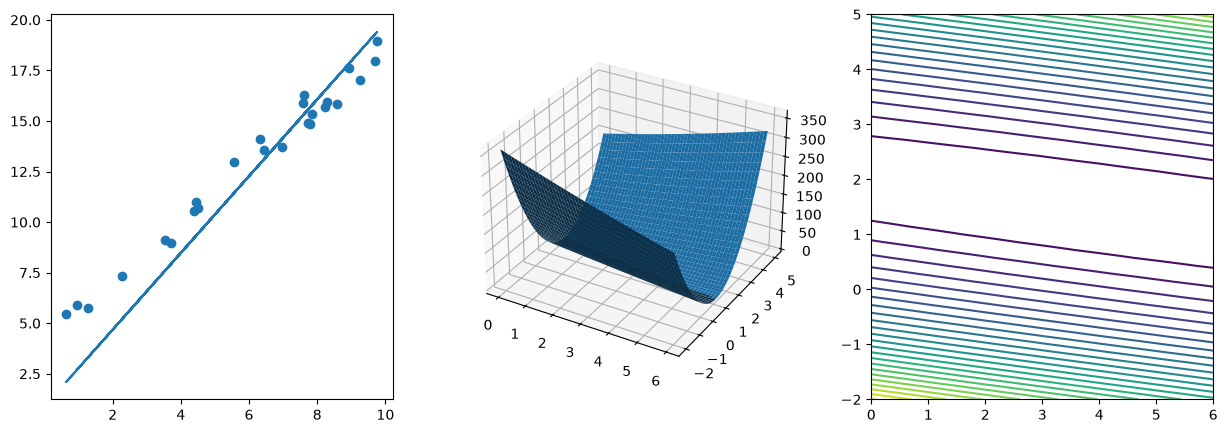

In [90]:
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax3 = fig.add_subplot(1, 3, 3)

ax1.scatter(x, y)
ax1.plot(x, thetas[-1][0] + thetas[-1][1]*x)

ax2.plot_surface(T0, T1, J, antialiased=True)

ax3.contour(T0, T1, J, levels=25)